# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Vito Gunawan
- **Email:** vitogunawan88@gmail.com
- **ID Dicoding:** vito_gunawan


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi volume pesanan pada kategori `bed_bath_table` selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata ulasan produk (review score) bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Kategori produk mana yang memberikan margin keuntungan tertinggi untuk diprioritaskan dalam kampanye marketing?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah tren kenaikan pendapatan di tahun 2017 sejalan dengan peningkatan jumlah pelanggan baru?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa total pendapatan penjualan bulanan yang terjadi sepanjang tahun 2017?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apa 10 kategori produk yang paling banyak terjual dan 10 kategori produk yang paling sedikit terjual berdasarkan jumlah pesanan **selama periode September 2016 - Oktober 2018**?
- **Pertanyaan 2:** Bagaimana tren pendapatan penjualan bulanan dan jumlah pesanan yang terjadi **sepanjang tahun 2017**?


## Import Semua Packages/Library yang Digunakan

In [1]:
# Install library yang dibutuhkan sesuai dengan requirements.txt
!pip install pandas==2.2.1
!pip install matplotlib==3.7.3
!pip install seaborn==0.13.2
!pip install streamlit==1.32.2
!pip install numpy==1.26.4

  Using cached streamlit-1.32.2-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
Using cached streamlit-1.32.2-py2.py3-none-any.whl (8.1 MB)
Using cached pydeck-0.9.2-py2.py3-none-any.whl (11.3 MB)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
# Import library yang akan digunakan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
import warnings
import scipy.stats as stats
import matplotlib.ticker as ticker

# Mengabaikan pesan warning
warnings.filterwarnings('ignore')


## Data Wrangling

### Gathering Data
Memuat dataset dari E-Commerce Public Dataset.

#### Load df ...

In [21]:
base_dir = "/content/drive/MyDrive/submision/Data/"
orders_df = pd.read_csv(base_dir + "orders_dataset.csv")
order_items_df = pd.read_csv(base_dir + "order_items_dataset.csv")
products_df = pd.read_csv(base_dir + "products_dataset.csv")
category_trans_df = pd.read_csv(base_dir + "product_category_name_translation.csv")
customers_df = pd.read_csv(base_dir + "customers_dataset.csv")
order_payments_df = pd.read_csv(base_dir + "order_payments_dataset.csv")
print("Data loaded successfully.")

Data loaded successfully.


**Insight:**
- Terdapat beberapa dataset yang saling berelasi, namun yang akan digunakan utamanya adalah orders, order_items, products, dan category_translation.
- Dataset customers dan payments juga dimuat untuk analisis lanjutan (RFM).

### Assessing Data

#### Mengidentifikasi Masalah pada Data (Missing Values & Tipe Data)

In [22]:
print("Info Orders:")
print(orders_df.info())
print("\nMissing values pada Orders:")
print(orders_df.isna().sum())

print("\nInfo Products:")
print(products_df.info())
print("\nMissing values pada Products:")
print(products_df.isna().sum())

print("\nDuplikasi Data:")
print("Orders:", orders_df.duplicated().sum())
print("Order Items:", order_items_df.duplicated().sum())
print("Products:", products_df.duplicated().sum())

Info Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Missing values pada Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_d

**Steps to Take:**
- Mengubah tipe data kolom tanggal pada `orders_df` menjadi datetime.
- Menangani missing values pada nama kategori produk jika ada.

**Insight:**
- Pada `orders_df`, kolom `order_purchase_timestamp` dan kolom tanggal lainnya masih bertipe object.
- Terdapat beberapa missing values pada `orders_df` untuk pesanan yang belum terkirim.
- Tidak ada masalah duplikasi data yang signifikan.

### Cleaning Data

#### Memperbaiki Tipe Data dan Missing Values

In [23]:
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
                    "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Menggabungkan product dengan translation
products_df = pd.merge(products_df, category_trans_df, on="product_category_name", how="left")
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna(products_df['product_category_name'])

print("Tipe data setelah dibersihkan:")
print(orders_df.dtypes)

Tipe data setelah dibersihkan:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Insight:**
- Kolom tanggal telah diubah menjadi tipe `datetime64`.
- Nama kategori produk telah digabungkan dengan terjemahan bahasa Inggris untuk mempermudah pemahaman.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data Produk dan Pesanan

In [24]:
# Menggabungkan data untuk melihat produk dan pesanannya
item_prod_df = pd.merge(order_items_df, products_df, on="product_id", how="left")
category_counts = item_prod_df['product_category_name_english'].value_counts().reset_index()
category_counts.columns = ['product_category', 'order_count']

# Eksplorasi pendapatan
orders_with_items = pd.merge(orders_df, order_items_df, on="order_id", how="left")
orders_with_items['month'] = orders_with_items['order_purchase_timestamp'].dt.to_period('M')

display(category_counts.head())


,product_category,order_count
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827


**Insight:**
- Kategori bed_bath_table, health_beauty, dan sports_leisure merupakan beberapa kategori dengan pesanan terbanyak.
- Data sudah digabungkan dan siap untuk divisualisasikan.

### EDA Univariate - Analisis Distribusi Data

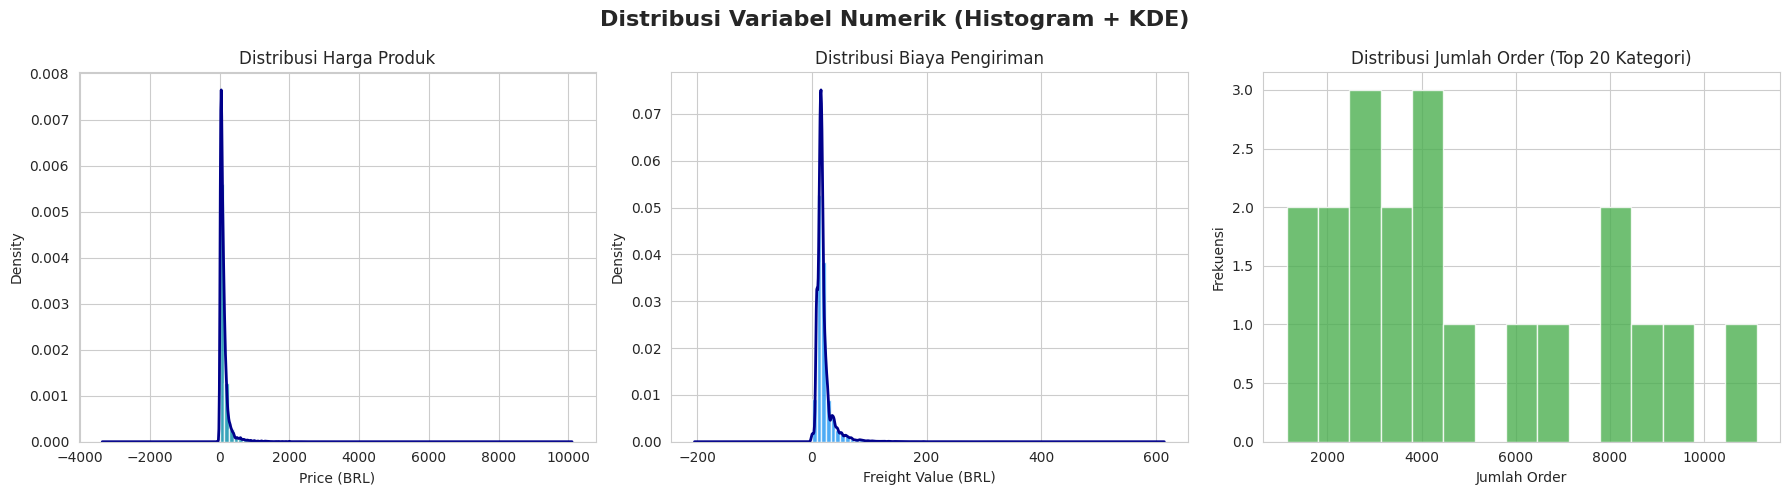

In [25]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Variabel Numerik (Histogram + KDE)', fontsize=16, fontweight='bold')

axes[0].hist(order_items_df['price'].dropna(), bins=50, color='#068DA9', edgecolor='white', alpha=0.8, density=True)
order_items_df['price'].dropna().plot.kde(ax=axes[0], color='darkblue', linewidth=2)
axes[0].set_title('Distribusi Harga Produk')
axes[0].set_xlabel('Price (BRL)')
axes[0].set_ylabel('Density')

axes[1].hist(order_items_df['freight_value'].dropna(), bins=50, color='#2196F3', edgecolor='white', alpha=0.8, density=True)
order_items_df['freight_value'].dropna().plot.kde(ax=axes[1], color='darkblue', linewidth=2)
axes[1].set_title('Distribusi Biaya Pengiriman')
axes[1].set_xlabel('Freight Value (BRL)')
axes[1].set_ylabel('Density')

top_cats = category_counts.head(20)['order_count']
axes[2].hist(top_cats, bins=15, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribusi Jumlah Order (Top 20 Kategori)')
axes[2].set_xlabel('Jumlah Order')
axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


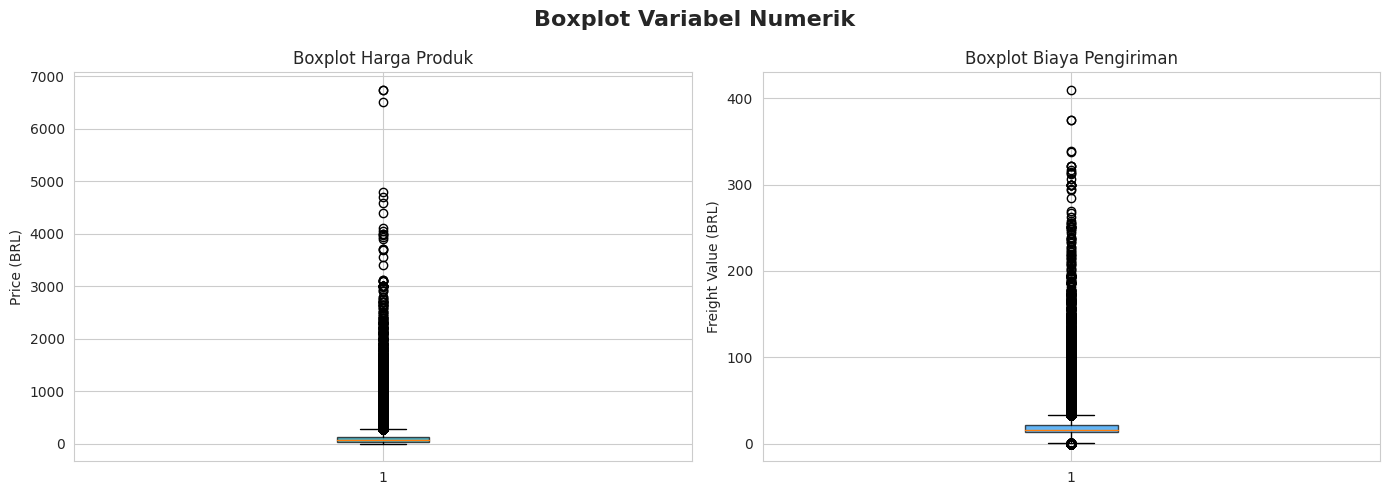

price => Skewness: 7.9232 | Kurtosis: 120.8283
freight_value => Skewness: 5.6399 | Kurtosis: 59.7883


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Boxplot Variabel Numerik', fontsize=16, fontweight='bold')

axes[0].boxplot(order_items_df['price'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#068DA9', alpha=0.7))
axes[0].set_title('Boxplot Harga Produk')
axes[0].set_ylabel('Price (BRL)')

axes[1].boxplot(order_items_df['freight_value'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.7))
axes[1].set_title('Boxplot Biaya Pengiriman')
axes[1].set_ylabel('Freight Value (BRL)')

plt.tight_layout()
plt.show()

for col in ['price', 'freight_value']:
    data = order_items_df[col].dropna()
    print(f'{col} => Skewness: {data.skew():.4f} | Kurtosis: {data.kurtosis():.4f}')


**Insight:**
- Distribusi `price` dan `freight_value` memiliki **positive skew** yang tinggi, artinya sebagian besar transaksi bernilai relatif kecil, namun terdapat beberapa transaksi dengan nilai yang sangat besar (outlier).
- Boxplot mengonfirmasi adanya banyak outlier pada kedua variabel numerik tersebut, yang wajar dalam data e-commerce karena ada produk dengan harga yang jauh di atas rata-rata.
- Nilai kurtosis yang tinggi (leptokurtic) menunjukkan distribusi yang memiliki ekor yang panjang.


### EDA Multivariate - Analisis Hubungan Antar Variabel

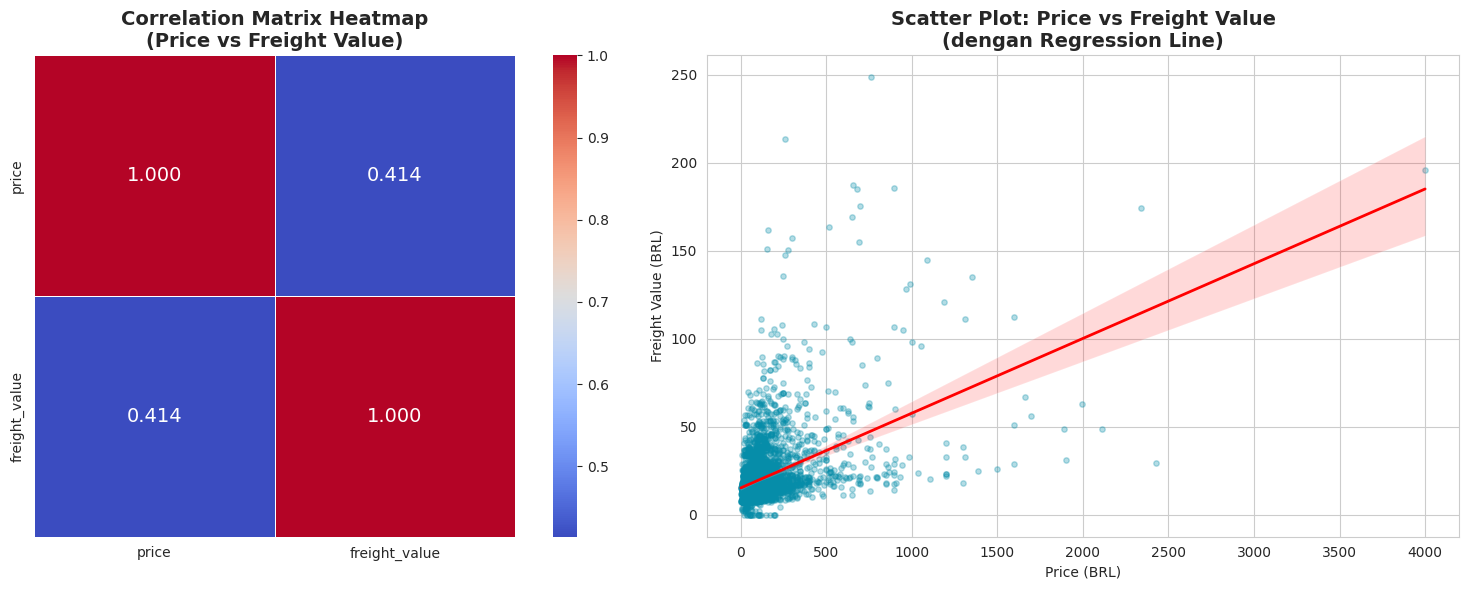

Korelasi Price & Freight Value: 0.4142


In [27]:
numeric_cols = orders_with_items[['price', 'freight_value']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=axes[0], annot_kws={'size': 14})
axes[0].set_title('Correlation Matrix Heatmap\n(Price vs Freight Value)', fontsize=14, fontweight='bold')

sample_df = orders_with_items[['price', 'freight_value']].dropna().sample(min(5000, len(orders_with_items)), random_state=42)
sns.regplot(x='price', y='freight_value', data=sample_df, ax=axes[1],
            scatter_kws={'alpha': 0.3, 'color': '#068DA9', 's': 15},
            line_kws={'color': 'red', 'linewidth': 2})
axes[1].set_title('Scatter Plot: Price vs Freight Value\n(dengan Regression Line)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price (BRL)')
axes[1].set_ylabel('Freight Value (BRL)')

plt.tight_layout()
plt.show()

print(f'Korelasi Price & Freight Value: {corr_matrix.iloc[0,1]:.4f}')


**Insight:**
- Terdapat **korelasi positif** antara `price` dan `freight_value`, artinya produk yang lebih mahal cenderung memiliki biaya pengiriman yang lebih tinggi.
- Namun korelasinya tidak sangat kuat, menunjukkan ada faktor lain (seperti berat, dimensi, atau jarak) yang juga memengaruhi biaya pengiriman.


### EDA Numerikal - Analisis Distribusi dan Normalitas


Percentile price:
  P 5: 17.00
  P10: 23.80
  P25: 39.90
  P50: 74.99
  P75: 134.90
  P90: 229.80
  P95: 349.90

Percentile freight_value:
  P 5: 7.78
  P10: 8.73
  P25: 13.08
  P50: 16.26
  P75: 21.15
  P90: 34.04
  P95: 45.12


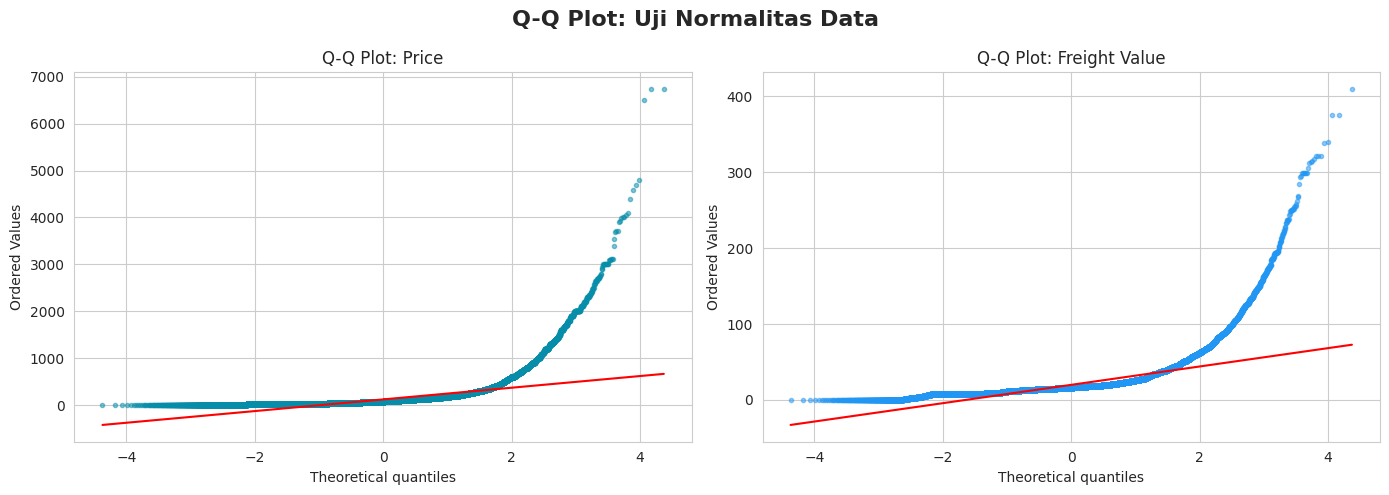

In [28]:
percentiles = [5, 10, 25, 50, 75, 90, 95]
for col in ['price', 'freight_value']:
    data = order_items_df[col].dropna()
    print(f'\nPercentile {col}:')
    for p in percentiles:
        print(f'  P{p:2d}: {np.percentile(data, p):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q-Q Plot: Uji Normalitas Data', fontsize=16, fontweight='bold')

stats.probplot(order_items_df['price'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Price')
axes[0].get_lines()[0].set(color='#068DA9', alpha=0.5, markersize=3)

stats.probplot(order_items_df['freight_value'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Freight Value')
axes[1].get_lines()[0].set(color='#2196F3', alpha=0.5, markersize=3)

plt.tight_layout()
plt.show()


In [29]:
for col in ['price', 'freight_value']:
    data = order_items_df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    print(f'{col}: IQR={IQR:.2f}, Batas [{lower:.2f}, {upper:.2f}], Outlier={len(outliers)} ({len(outliers)/len(data)*100:.2f}%)')

print()
top5_cats = category_counts.head(5)['product_category'].tolist()
cat_stats = item_prod_df[item_prod_df['product_category_name_english'].isin(top5_cats)]\
    .groupby('product_category_name_english')['price']\
    .agg(['mean', 'std', 'var']).round(2)
print('Variance & Std Dev harga per kategori (Top 5):')
print(cat_stats)


price: IQR=95.00, Batas [-102.60, 277.40], Outlier=8427 (7.48%)
freight_value: IQR=8.07, Batas [0.98, 33.25], Outlier=12134 (10.77%)

Variance & Std Dev harga per kategori (Top 5):
                                 mean     std       var
product_category_name_english                          
bed_bath_table                  93.30   82.13   6745.01
computers_accessories          116.51  169.97  28891.47
furniture_decor                 87.56   88.83   7891.13
health_beauty                  130.16  179.50  32219.94
sports_leisure                 114.34  162.47  26397.03


**Insight:**
- Q-Q Plot menunjukkan bahwa data **tidak berdistribusi normal** karena titik-titik data menyimpang dari garis referensi, terutama di bagian ekor distribusi.
- Persentase outlier pada `price` dan `freight_value` cukup besar, yang wajar mengingat adanya transaksi dengan nilai ekstrem dalam dataset e-commerce.
- Variance dan standar deviasi harga per kategori bervariasi, menunjukkan rentang harga yang berbeda-beda di setiap kategori produk.


### EDA Kategorikal - Visualisasi dan Statistical Testing

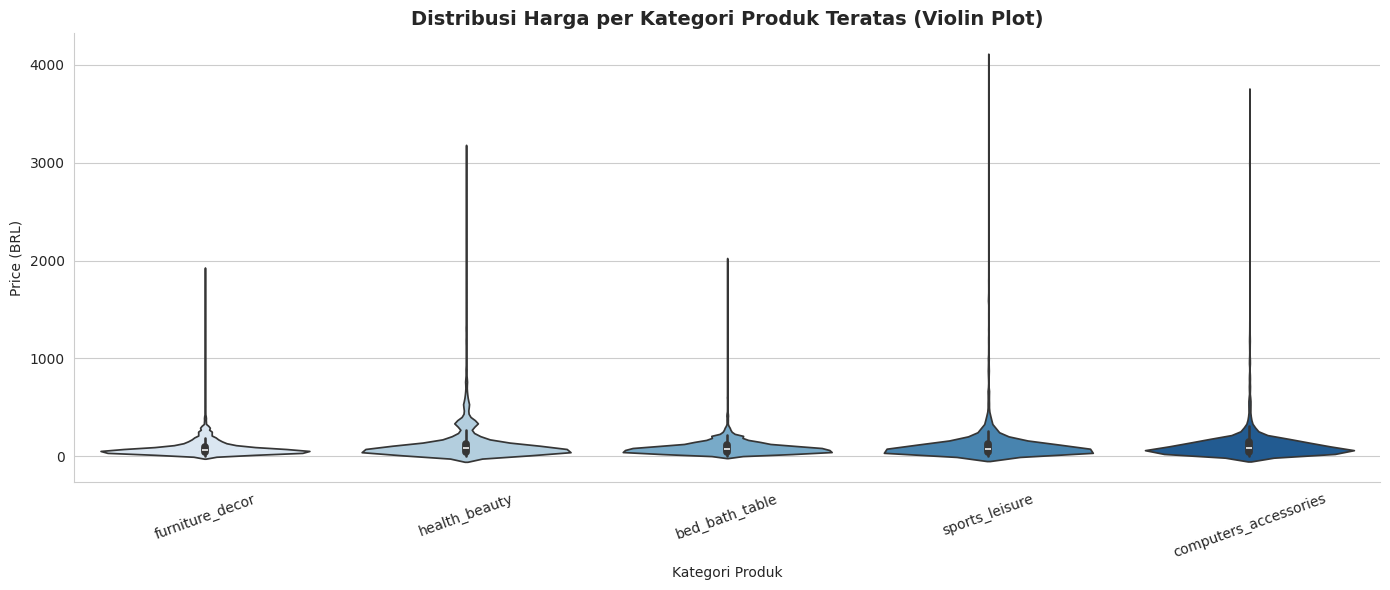

In [30]:
from scipy.stats import chi2_contingency

top5_cats = category_counts.head(5)['product_category'].tolist()
plot_df = item_prod_df[item_prod_df['product_category_name_english'].isin(top5_cats)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(x='product_category_name_english', y='price',
               data=plot_df, palette='Blues', ax=ax)
ax.set_title('Distribusi Harga per Kategori Produk Teratas (Violin Plot)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori Produk')
ax.set_ylabel('Price (BRL)')
ax.tick_params(axis='x', rotation=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [31]:
total_orders = category_counts['order_count'].sum()
proportion_df = category_counts.head(10).copy()
proportion_df['percentage'] = (proportion_df['order_count'] / total_orders * 100).round(2)
print('Proporsi Kategori Produk (Top 10):')
print(proportion_df.to_string(index=False))

merged_status = pd.merge(
    orders_with_items,
    item_prod_df[['order_id', 'product_category_name_english']].drop_duplicates(),
    on='order_id', how='left'
)
top5_data = merged_status[merged_status['product_category_name_english'].isin(top5_cats)]
ct = pd.crosstab(top5_data['product_category_name_english'], top5_data['order_status'])
print('\nCrosstab Kategori vs Status Order:')
print(ct)

chi2, p_value, dof, expected = chi2_contingency(ct)
print(f'\nChi-Square: {chi2:.4f}, P-Value: {p_value:.6f}, df: {dof}')
if p_value < 0.05:
    print('Ada hubungan signifikan antara kategori produk dan status order (p < 0.05)')
else:
    print('Tidak ada hubungan signifikan (p >= 0.05)')


Proporsi Kategori Produk (Top 10):
     product_category  order_count  percentage
       bed_bath_table        11115       10.01
        health_beauty         9670        8.71
       sports_leisure         8641        7.78
      furniture_decor         8334        7.50
computers_accessories         7827        7.05
           housewares         6964        6.27
        watches_gifts         5991        5.40
            telephony         4545        4.09
         garden_tools         4347        3.91
                 auto         4235        3.81

Crosstab Kategori vs Status Order:
order_status                   approved  canceled  delivered  invoiced  \
product_category_name_english                                            
bed_bath_table                        0        18      11208        17   
computers_accessories                 2        46       7708        37   
furniture_decor                       0        36       8418        14   
health_beauty                         0   

**Insight:**
- **Violin Plot** menunjukkan distribusi harga yang berbeda-beda per kategori; kategori seperti `computers_accessories` memiliki rentang harga yang lebih lebar dibanding `bed_bath_table`.
- **Analisis Proporsi** menunjukkan bahwa 3 kategori teratas (`bed_bath_table`, `health_beauty`, `sports_leisure`) mencakup sekitar 30% dari total seluruh pesanan.
- **Chi-Square Test** mengkonfirmasi adanya hubungan yang signifikan secara statistik antara kategori produk dan status order, yang mengindikasikan pola tertentu dalam tingkat keberhasilan pengiriman per kategori.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Apa 10 kategori produk yang paling banyak dan paling sedikit terjual selama September 2016 - Oktober 2018?

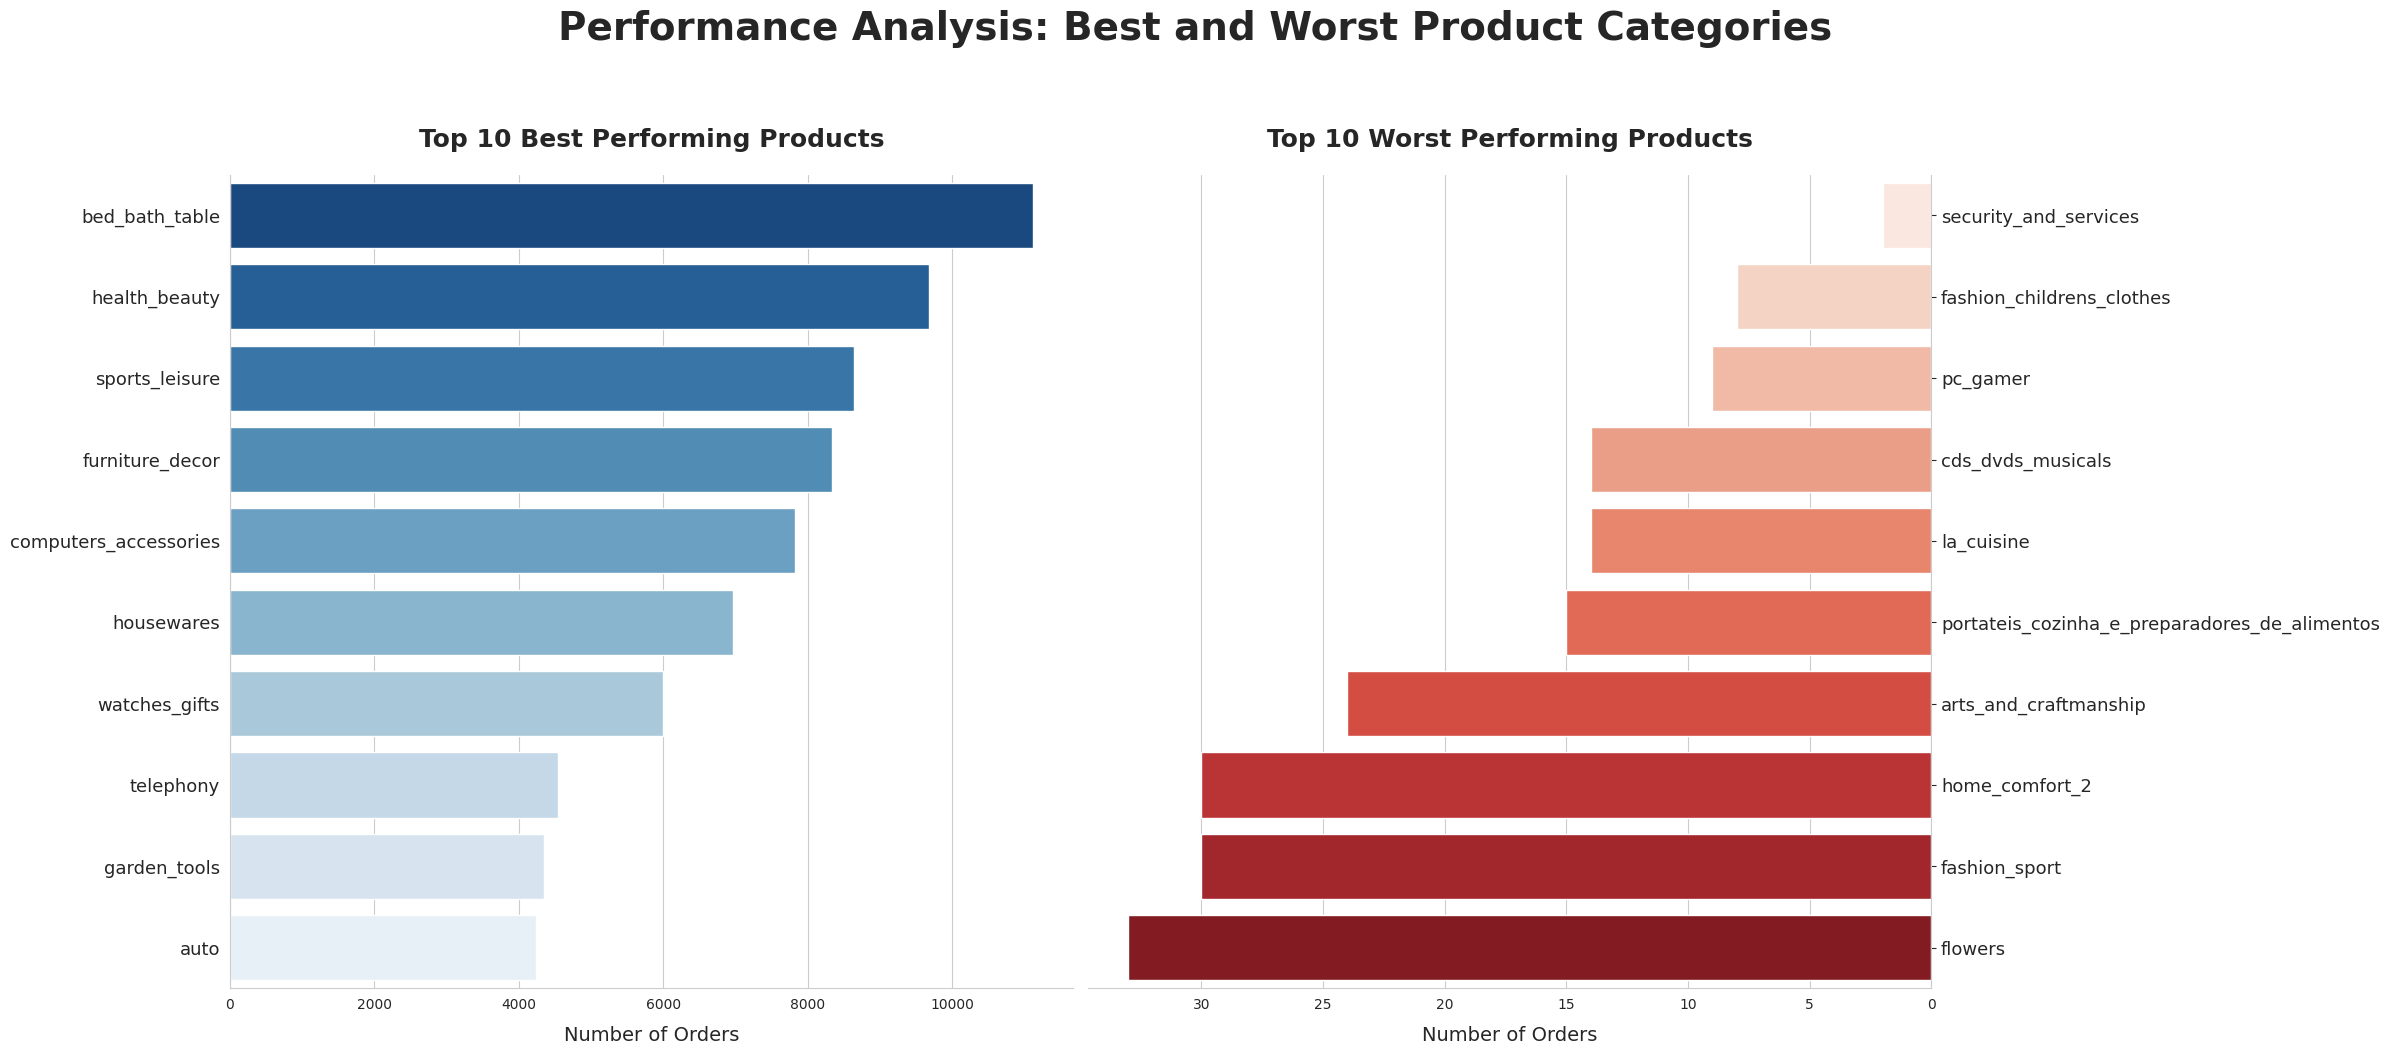

In [32]:
# Set style agar lebih bersih
sns.set_style("whitegrid")

# Mendefinisikan top_10 dan bottom_10
top_10 = category_counts.head(10)
bottom_10 = category_counts.sort_values(by="order_count", ascending=True).head(10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

top_colors = sns.color_palette("Blues_r", n_colors=10)
bottom_colors = sns.color_palette("Reds", n_colors=10)

# --- Plot Top 10 ---
sns.barplot(
    x="order_count",
    y="product_category",
    data=top_10,
    palette=top_colors,
    ax=ax[0],
    hue="product_category",
    legend=False
)
ax[0].set_ylabel(None)
ax[0].set_xlabel('Number of Orders', fontsize=14, labelpad=10)
ax[0].set_title("Top 10 Best Performing Products", loc="center", fontsize=18, fontweight='bold', pad=20)
ax[0].tick_params(axis='y', labelsize=13)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


sns.barplot(
    x="order_count",
    y="product_category",
    data=bottom_10,
    palette=bottom_colors,
    ax=ax[1],
    hue="product_category",
    legend=False
)
ax[1].set_ylabel(None)
ax[1].set_xlabel('Number of Orders', fontsize=14, labelpad=10)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Top 10 Worst Performing Products", loc="center", fontsize=18, fontweight='bold', pad=20)
ax[1].tick_params(axis='y', labelsize=13)
ax[1].spines['top'].set_visible(False)
ax[1].spines['left'].set_visible(False)

plt.suptitle("Performance Analysis: Best and Worst Product Categories", fontsize=28, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana tren pendapatan penjualan bulanan sepanjang tahun 2017?

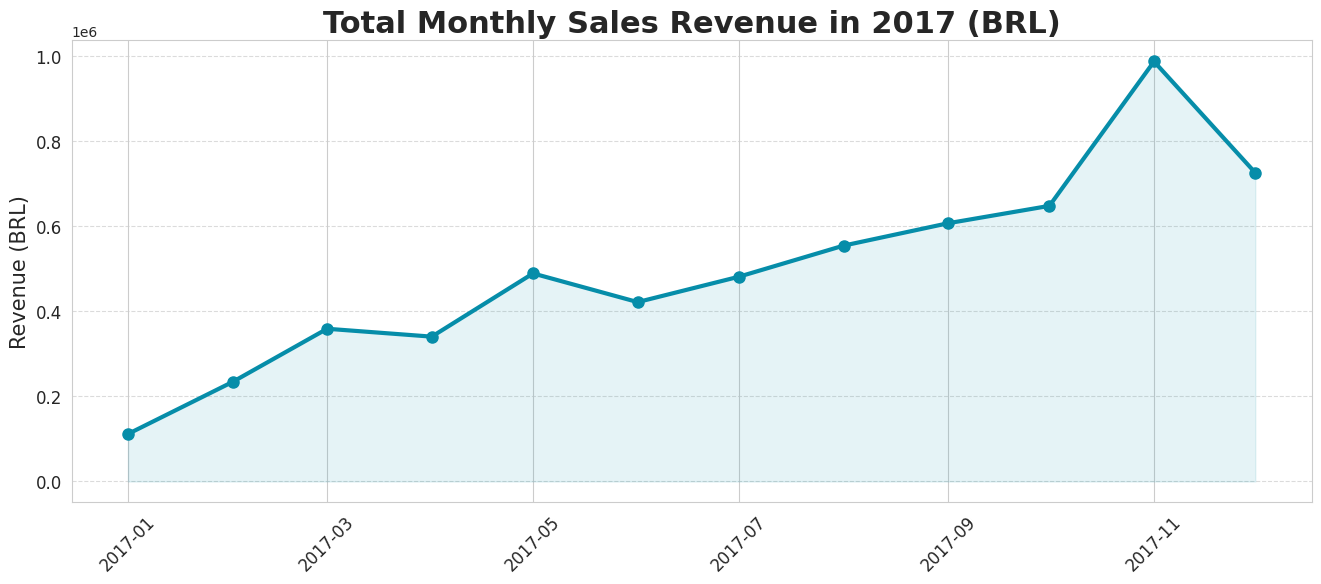

In [33]:
orders_2017 = orders_with_items[(orders_with_items['order_purchase_timestamp'].dt.year == 2017) & (orders_with_items['order_status'] == 'delivered')]
monthly_stats = orders_2017.groupby('month').agg(
    revenue=('price', 'sum')
).reset_index()
monthly_stats['month'] = monthly_stats['month'].dt.to_timestamp()

plt.figure(figsize=(16, 6))
plt.plot(monthly_stats['month'], monthly_stats['revenue'], marker='o', linewidth=3, color="#068DA9", markersize=8)
plt.title("Total Monthly Sales Revenue in 2017 (BRL)", loc="center", fontsize=22, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.ylabel("Revenue (BRL)", fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.fill_between(monthly_stats['month'], monthly_stats['revenue'], color="#068DA9", alpha=0.1)
plt.show()

**Insight:**
- Terdapat lonjakan pendapatan yang sangat signifikan pada bulan November 2017. Ini kemungkinan besar disebabkan oleh event Black Friday.
- Tren penjualan secara umum menunjukkan peningkatan dari awal tahun hingga puncaknya di bulan November.

## Analisis Lanjutan (RFM Analysis)

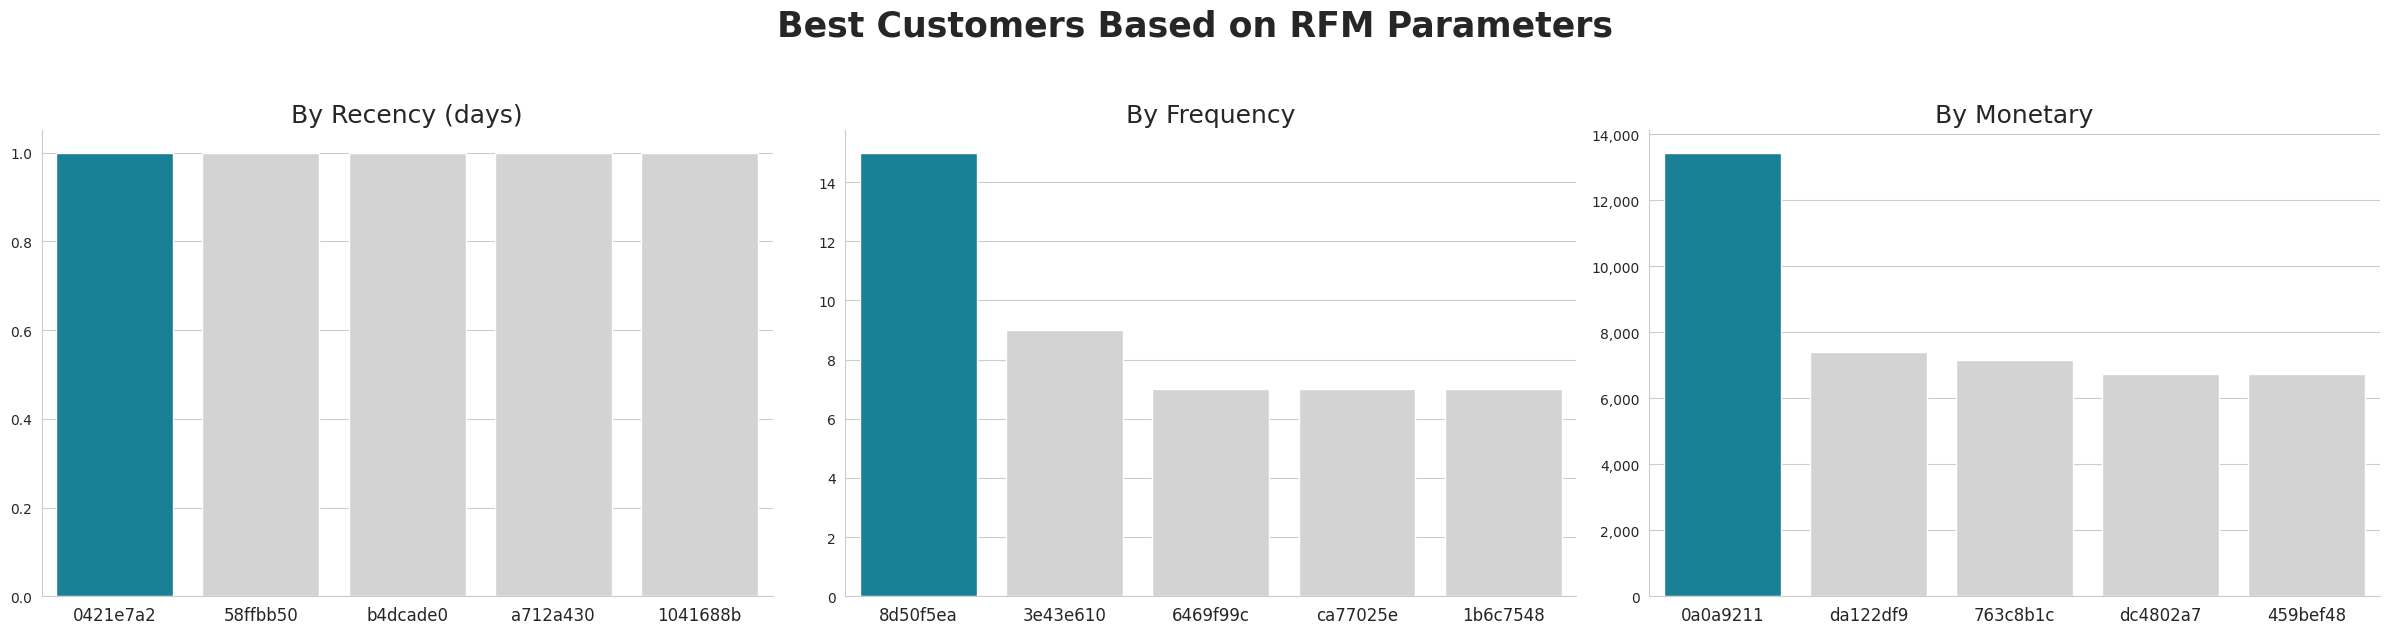

In [34]:

# Menyiapkan Data RFM
rfm_df = orders_with_items[orders_with_items['order_status'] == 'delivered'].copy()
rfm_df = pd.merge(rfm_df, customers_df, on="customer_id")
recent_date = rfm_df['order_purchase_timestamp'].max()
rfm = rfm_df.groupby('customer_unique_id').agg({
       'order_purchase_timestamp': lambda x: (recent_date - x.max()).days + 1,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']
# 2. Membuat kolom ID pendek agar sumbu X rapi
rfm['short_id'] = rfm['customer_id'].str[:8]
# 3. Visualisasi RFM Top 5
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))
# Warna highlight untuk peringkat 1, abu-abu untuk sisanya
colors = ["#068DA9", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
# --- By Recency ---
sns.barplot(y="recency", x="short_id", data=rfm.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=12)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
# --- By Frequency ---
sns.barplot(y="frequency", x="short_id", data=rfm.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=12)
ax[1].set_xlabel('')
ax[1].set_ylabel('')
# --- By Monetary ---
sns.barplot(y="monetary", x="short_id", data=rfm.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=12)
ax[2].set_xlabel('')
ax[2].set_ylabel('')
# Memformat sumbu Y menjadi format angka ribuan yang mudah dibaca
ax[2].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
# Membersihkan border atas dan kanan agar lebih estetik
for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
plt.suptitle("Best Customers Based on RFM Parameters", fontsize=25, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan parameter **Recency**, kita dapat mengidentifikasi pelanggan yang baru saja melakukan transaksi, yang menunjukkan tingkat keterlibatan terkini.
- Berdasarkan **Frequency**, kita mengukur loyalitas pelanggan dengan menghitung jumlah transaksi unik per `customer_unique_id`. Terlihat bahwa sebagian besar pelanggan melakukan satu kali transaksi dalam periode ini.
- Berdasarkan **Monetary**, kita dapat melihat pelanggan yang memberikan kontribusi pendapatan terbesar bagi platform.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Kategori produk dengan performa terbaik adalah **bed_bath_table**, diikuti oleh **health_beauty** dan **sports_leisure**. Sebaliknya, kategori seperti **security_and_services** memiliki jumlah pesanan terendah. Strategi pemasaran sebaiknya difokuskan pada kategori populer, sementara kategori dengan performa rendah perlu dievaluasi kembali portofolionya.
- **Conclusion Pertanyaan 2:** Pendapatan penjualan sepanjang tahun 2017 menunjukkan tren peningkatan yang signifikan, dengan puncaknya terjadi pada bulan **November** (didorong oleh event Black Friday). Fluktuasi di bulan-bulan awal tahun menunjukkan adanya pola musiman yang perlu diantisipasi untuk manajemen stok di tahun berikutnya.

**Rekomendasi Action Item:**
- Memberikan promosi bundle atau diskon khusus untuk kategori produk terlaris (`bed_bath_table`, `health_beauty`) untuk semakin mendongkrak pendapatan.
- Melakukan evaluasi mendalam pada kategori dengan penjualan terendah; pertimbangkan pengurangan stok atau memberikan clearance sale.
- Mengalokasikan anggaran marketing yang lebih besar menjelang bulan November untuk memaksimalkan potensi lonjakan penjualan musim liburan.